In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [24]:
os.chdir(r"C:\Users\Asus\Downloads\data cnn")

In [25]:
os.getcwd()

'C:\\Users\\Asus\\Downloads\\data cnn'

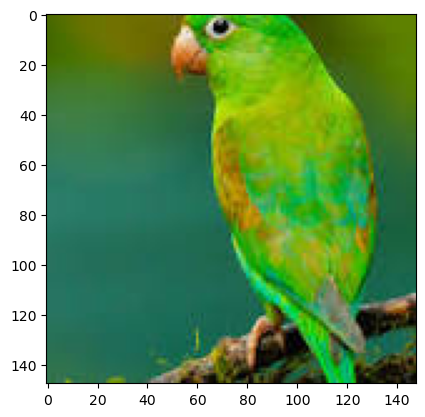

In [26]:
img = image.load_img(r"C:\Users\Asus\Downloads\data cnn\training\parrot\parrot 3.jpg")
plt.imshow(img)

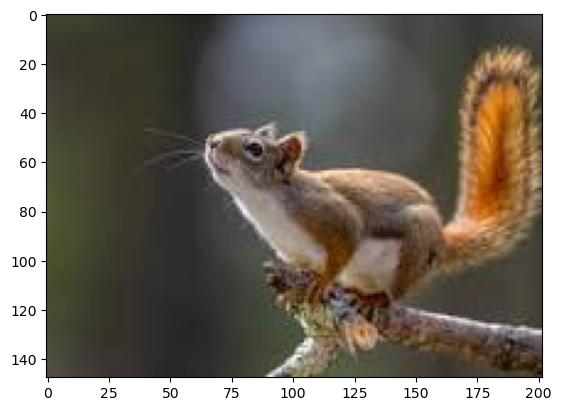

In [27]:
img = image.load_img(r"C:\Users\Asus\Downloads\data cnn\training\squirrel\squirrel 5.jpg")
plt.imshow(img)

In [28]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [29]:
tr_location = r"C:\Users\Asus\Downloads\data cnn\training"
val_location = r"C:\Users\Asus\Downloads\data cnn\validation"


In [30]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 12 images belonging to 2 classes.
Found 12 images belonging to 2 classes.


In [31]:
train_data.class_indices

{'parrot': 0, 'squirrel': 1}

In [32]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [40]:
model.fit(train_data,  epochs=25,  validation_data=valid_data)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8333 - loss: 0.5022 - val_accuracy: 0.8333 - val_loss: 0.3200
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9167 - loss: 0.2503 - val_accuracy: 1.0000 - val_loss: 0.0475
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 1.0000 - loss: 0.0411 - val_accuracy: 1.0000 - val_loss: 0.0198
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 1.0000 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 0.0065
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss:

In [41]:
print(train_data.class_indices)

{'parrot': 0, 'squirrel': 1}


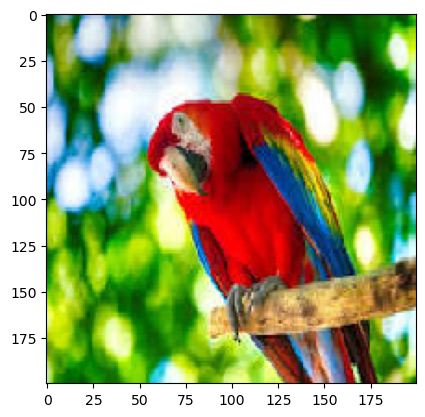

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
parrot


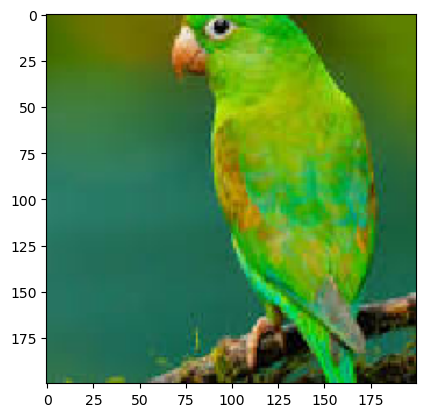

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
parrot


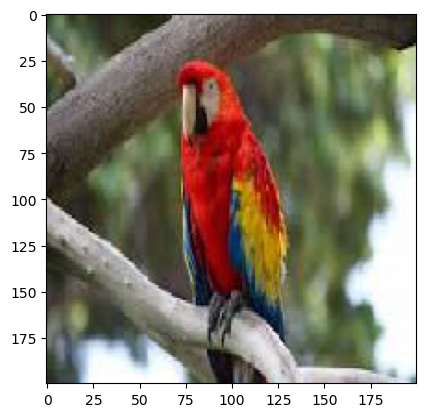

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
parrot


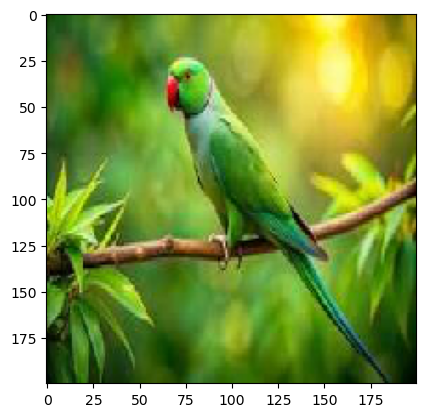

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
parrot


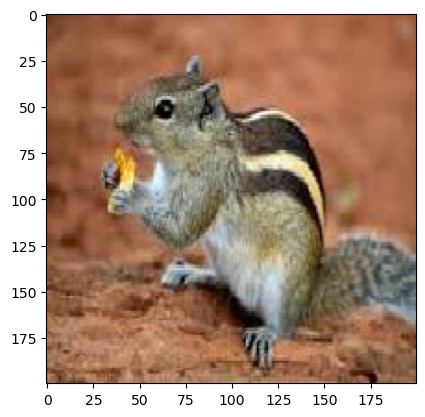

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
squirrel


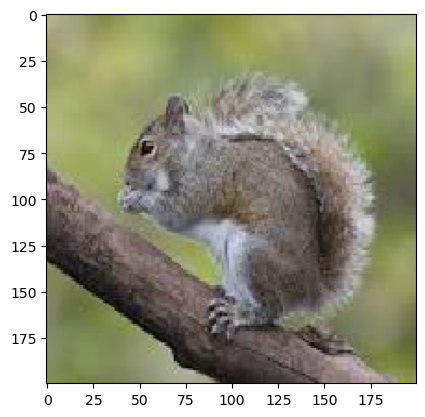

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
squirrel


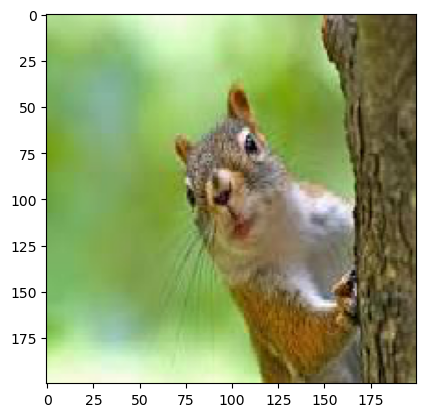

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
squirrel


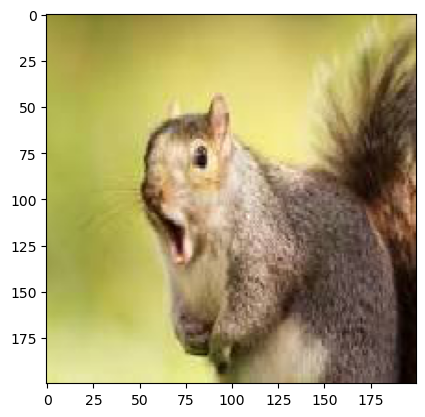

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
squirrel


In [42]:
path = r"C:\Users\Asus\Downloads\data cnn\testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("parrot")
    else:
        print("squirrel")